##### Copyright 2026 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Agentic RAG

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/tutorials/Agentic_RAG.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

## Overview: Trace and Montior Agentic RAG using Google ADK, Gemma-4, Qdrant and OPIK

Build a gemma-4-31b-it powered Agentic RAG system that intelligently decides when to call functions, uses a Qdrant based RAG pipeline to fetch relevant information from your data, and falls back to Google Search when the required information is not available. Trace and monitor these calls with OPIK.

## Setup

Before starting this tutorial, complete the following steps:

* Switch to Nvidia T4 GPU on colab by selecting Runtime and change runtime type.
* Get your Gemini API Key from AI Studio: [aistudio.google.com](https://aistudio.google.com/api-keys)
* Get your Qdrant API Key and Endpoint by creating a cluster here: [cloud.qdrant.io](http://cloud.qdrant.io/)
* Get your OPIK API Key for tracing and monitoring: [comet.com/opik](https://www.comet.com/opik/). First create a new project and use that inside OPIK_PROJECT_NAME and by default on the top-right you will find your workspace name.

In [ ]:
!pip install qdrant-client opik fastembed pypdfium2
!pip install google-adk

In [1]:
import os
from google.colab import userdata

In [3]:
os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')
os.environ['OPIK_API_KEY'] = userdata.get("OPIK_API_KEY")
os.environ["OPIK_WORKSPACE"] = "tarun-r-jain"
os.environ["OPIK_PROJECT_NAME"] = "gemma4-oss"

QDRANT_URL = userdata.get('QDRANT_URL')
QDRANT_API_KEY = userdata.get('QDRANT_API_KEY')

In [59]:
import nest_asyncio
nest_asyncio.apply()

import asyncio
import logging
logging.getLogger("asyncio").setLevel(logging.CRITICAL)

## Document Processing

In [5]:
!wget https://data.imf.org/-/media/iData/External-Storage/Documents/7FC05452C6C743D2BFB6188D2E248A38/en/2025-FAS-Annual-Report.pdf -O annual_report.pdf

--2026-04-17 17:30:15--  https://data.imf.org/-/media/iData/External-Storage/Documents/7FC05452C6C743D2BFB6188D2E248A38/en/2025-FAS-Annual-Report.pdf
Resolving data.imf.org (data.imf.org)... 23.52.42.156, 23.52.42.137, 2600:1407:3c00:cc::172d:2ec8, ...
Connecting to data.imf.org (data.imf.org)|23.52.42.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1979418 (1.9M) [application/pdf]
Saving to: ‘annual_report.pdf’

annual_report.pdf   100%[===================>]   1.89M  --.-KB/s    in 0.1s    

2026-04-17 17:30:18 (18.8 MB/s) - ‘annual_report.pdf’ saved [1979418/1979418]



In [6]:
import pypdfium2 as pdfium
import re

In [7]:
def extract_text_from_pdf(pdf_path):
    doc = pdfium.PdfDocument(pdf_path)
    text_content = []
    for i in range(len(doc)):
        page = doc.get_page(i)
        text_page = page.get_textpage()
        text_content.append(text_page.get_text_range())
        text_page.close()
        page.close()
    doc.close()
    return text_content

annual_report_text = extract_text_from_pdf('annual_report.pdf')

In [8]:
len(annual_report_text)

31

In [9]:
def chunk_text(text_list, chunk_size=1500, overlap=0, source_doc="annual_report.pdf"):
    chunks = []
    for page_num, page_text in enumerate(text_list):
        for i in range(0, len(page_text), chunk_size - overlap):
            chunk_content = page_text[i : i + chunk_size].strip()
            if chunk_content:
                chunks.append({
                    "content": chunk_content,
                    "metadata": {
                        "source": source_doc,
                        "page_number": page_num + 1
                    }
                })
    return chunks

chunks = chunk_text(annual_report_text)

In [10]:
chunks = chunk_text(annual_report_text)
len(chunks)

70

## Index your data into Vector Search Engine

In [11]:
from qdrant_client import QdrantClient,models
from fastembed import TextEmbedding
import uuid

In [12]:
COLLECTION_NAME = "annual_report"
DENSE_MODEL_NAME = "jinaai/jina-embeddings-v2-small-en"

In [14]:
embedding_model = TextEmbedding(model_name=DENSE_MODEL_NAME)
client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)

In [15]:
client.create_collection(
    collection_name = COLLECTION_NAME,
    vectors_config = {
        "dense": models.VectorParams(
            size = 512,
            distance = models.Distance.COSINE
    )})

True

In [16]:
points = []

for doc in chunks:
    content = doc['content'].strip()
    embedding = list(embedding_model.embed([content]))[0].tolist()

    point = models.PointStruct(
        id=str(uuid.uuid4()),

        vector={"dense": embedding},

        payload={
            "content": content,
            "source": doc['metadata'].get("source"),
            "page_number": doc['metadata'].get("page_number"),
        }
    )
    points.append(point)

In [17]:
client.upsert(
    collection_name=COLLECTION_NAME,
    points=points
)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

## Test the index data - Knowledge base tool

In [18]:
def knowledge_base_tool(query: str) -> str:
  """
  Fetch the relevant documents from the knowledge base for the given user query.
  """
  query_embedding = list(embedding_model.embed([query]))[0].tolist()

  response = client.query_points(
      collection_name = COLLECTION_NAME,
      query = query_embedding,
      with_payload = True,
      using = "dense",
      limit = 3,
  ).points

  context = [text.payload['content'] for text in response]
  return "/n".join(context)

In [19]:
query = "projected reach of the digital remittance market by 2034"
knowledge_base_tool(query)

'mittance market is projected to reach USD 83.2–103.26 billion by 2034, growing at a robust \r\ncompound annual growth rate of 13.5 to 16.3 percent (Precedence Research, 2025). Digital platforms \r\nhave reduced their costs to 5 percent, compared to the average 7 percent of traditional channels, with \r\nfurther decreases anticipated as technologies like blockchain and stablecoins evolve. These cost savings \r\nare critical for low- and middle-income countries (LMICs), where remittances are a vital source of \r\nhousehold income (World Bank’s Remittance Price Worldwide). As the industry advances, digital \r\nremittance services will become essential in achieving the United Nations Sustainable Development \r\nGoals (SDGs), supporting economic empowerment, poverty reduction, and equitable access to and use \r\nof the global financial system.\r\nTransformative Innovations in Remittance Services\r\nArtificial Intelligence (AI): AI is making remittances more efficient and secure by enhancin

## Trace and Monitor using OPIK Initialization

In [20]:
from opik.integrations.adk import OpikTracer, track_adk_agent_recursive
opik_tracer = OpikTracer(name="agentic-rag")

/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


## Define Agent

In [47]:
from google.adk.agents import LlmAgent
from google.adk.models import Gemini

In [48]:
model_name = "gemma-4-31b-it"

In [60]:
knowledge_agent = LlmAgent(
    name="knowledge_base_agent",
    model=Gemini(model=model_name),
    description="Answers questions about the Financial Annual Survey Report by retrieving relevant sections from the knowledge base.",
    instruction="""
    You are a financial research assistant with access to the Financial Annual Survey Report.

    When the user asks a question:
    1. Use the knowledge_base_tool to fetch relevant information first.
    2. Answer strictly based on what the tool returns. Do not make up numbers or facts.
    3. If the tool returns no relevant data, tell the user the information is not available in the report.
    """,
    tools=[knowledge_base_tool]
)

## Execute the Agent and Trace the response

In [61]:
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService

import asyncio
from google.genai import types

In [62]:
track_adk_agent_recursive(knowledge_agent, opik_tracer)

LlmAgent(name='knowledge_base_agent', description='Answers questions about the Financial Annual Survey Report by retrieving relevant sections from the knowledge base.', parent_agent=None, sub_agents=[], before_agent_callback=<bound method OpikTracer.before_agent_callback of <opik.integrations.adk.opik_tracer.OpikTracer object at 0x7df079d31be0>>, after_agent_callback=<bound method OpikTracer.after_agent_callback of <opik.integrations.adk.opik_tracer.OpikTracer object at 0x7df079d31be0>>, model=Gemini(model='gemma-4-31b-it', base_url=None, speech_config=None, use_interactions_api=False, retry_options=None), instruction='\n    You are a financial research assistant with access to the Financial Annual Survey Report.\n\n    When the user asks a question:\n    1. Use the knowledge_base_tool to fetch relevant information first.\n    2. Answer strictly based on what the tool returns. Do not make up numbers or facts.\n    3. If the tool returns no relevant data, tell the user the information i

In [63]:
APP_NAME   = "agentic-rag"
USER_ID    = "user01"
SESSION_ID = "session01"

In [64]:
session_service = InMemorySessionService()

session = asyncio.run(session_service.create_session(
    app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID
))

In [65]:
def call_agent(query):
    runner = Runner(agent=knowledge_agent,
                    app_name=APP_NAME,
                    session_service=session_service)

    content = types.Content(role='user', parts=[types.Part(text=query)])

    events = runner.run(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

    for event in events:
        if event.is_final_response() and event.content:
            answer = event.content.parts[0].text.strip()
            print(answer)

In [55]:
print(query)

projected reach of the digital remittance market by 2034


In [56]:
call_agent(query)

The tool returned a section stating: "The digital remittance market is projected to reach USD 83.2–103.26 billion by 2034, growing at a robust compound annual growth rate of 13.5 to 16.3 percent (Precedence Research, 2025)."
I have the answer.


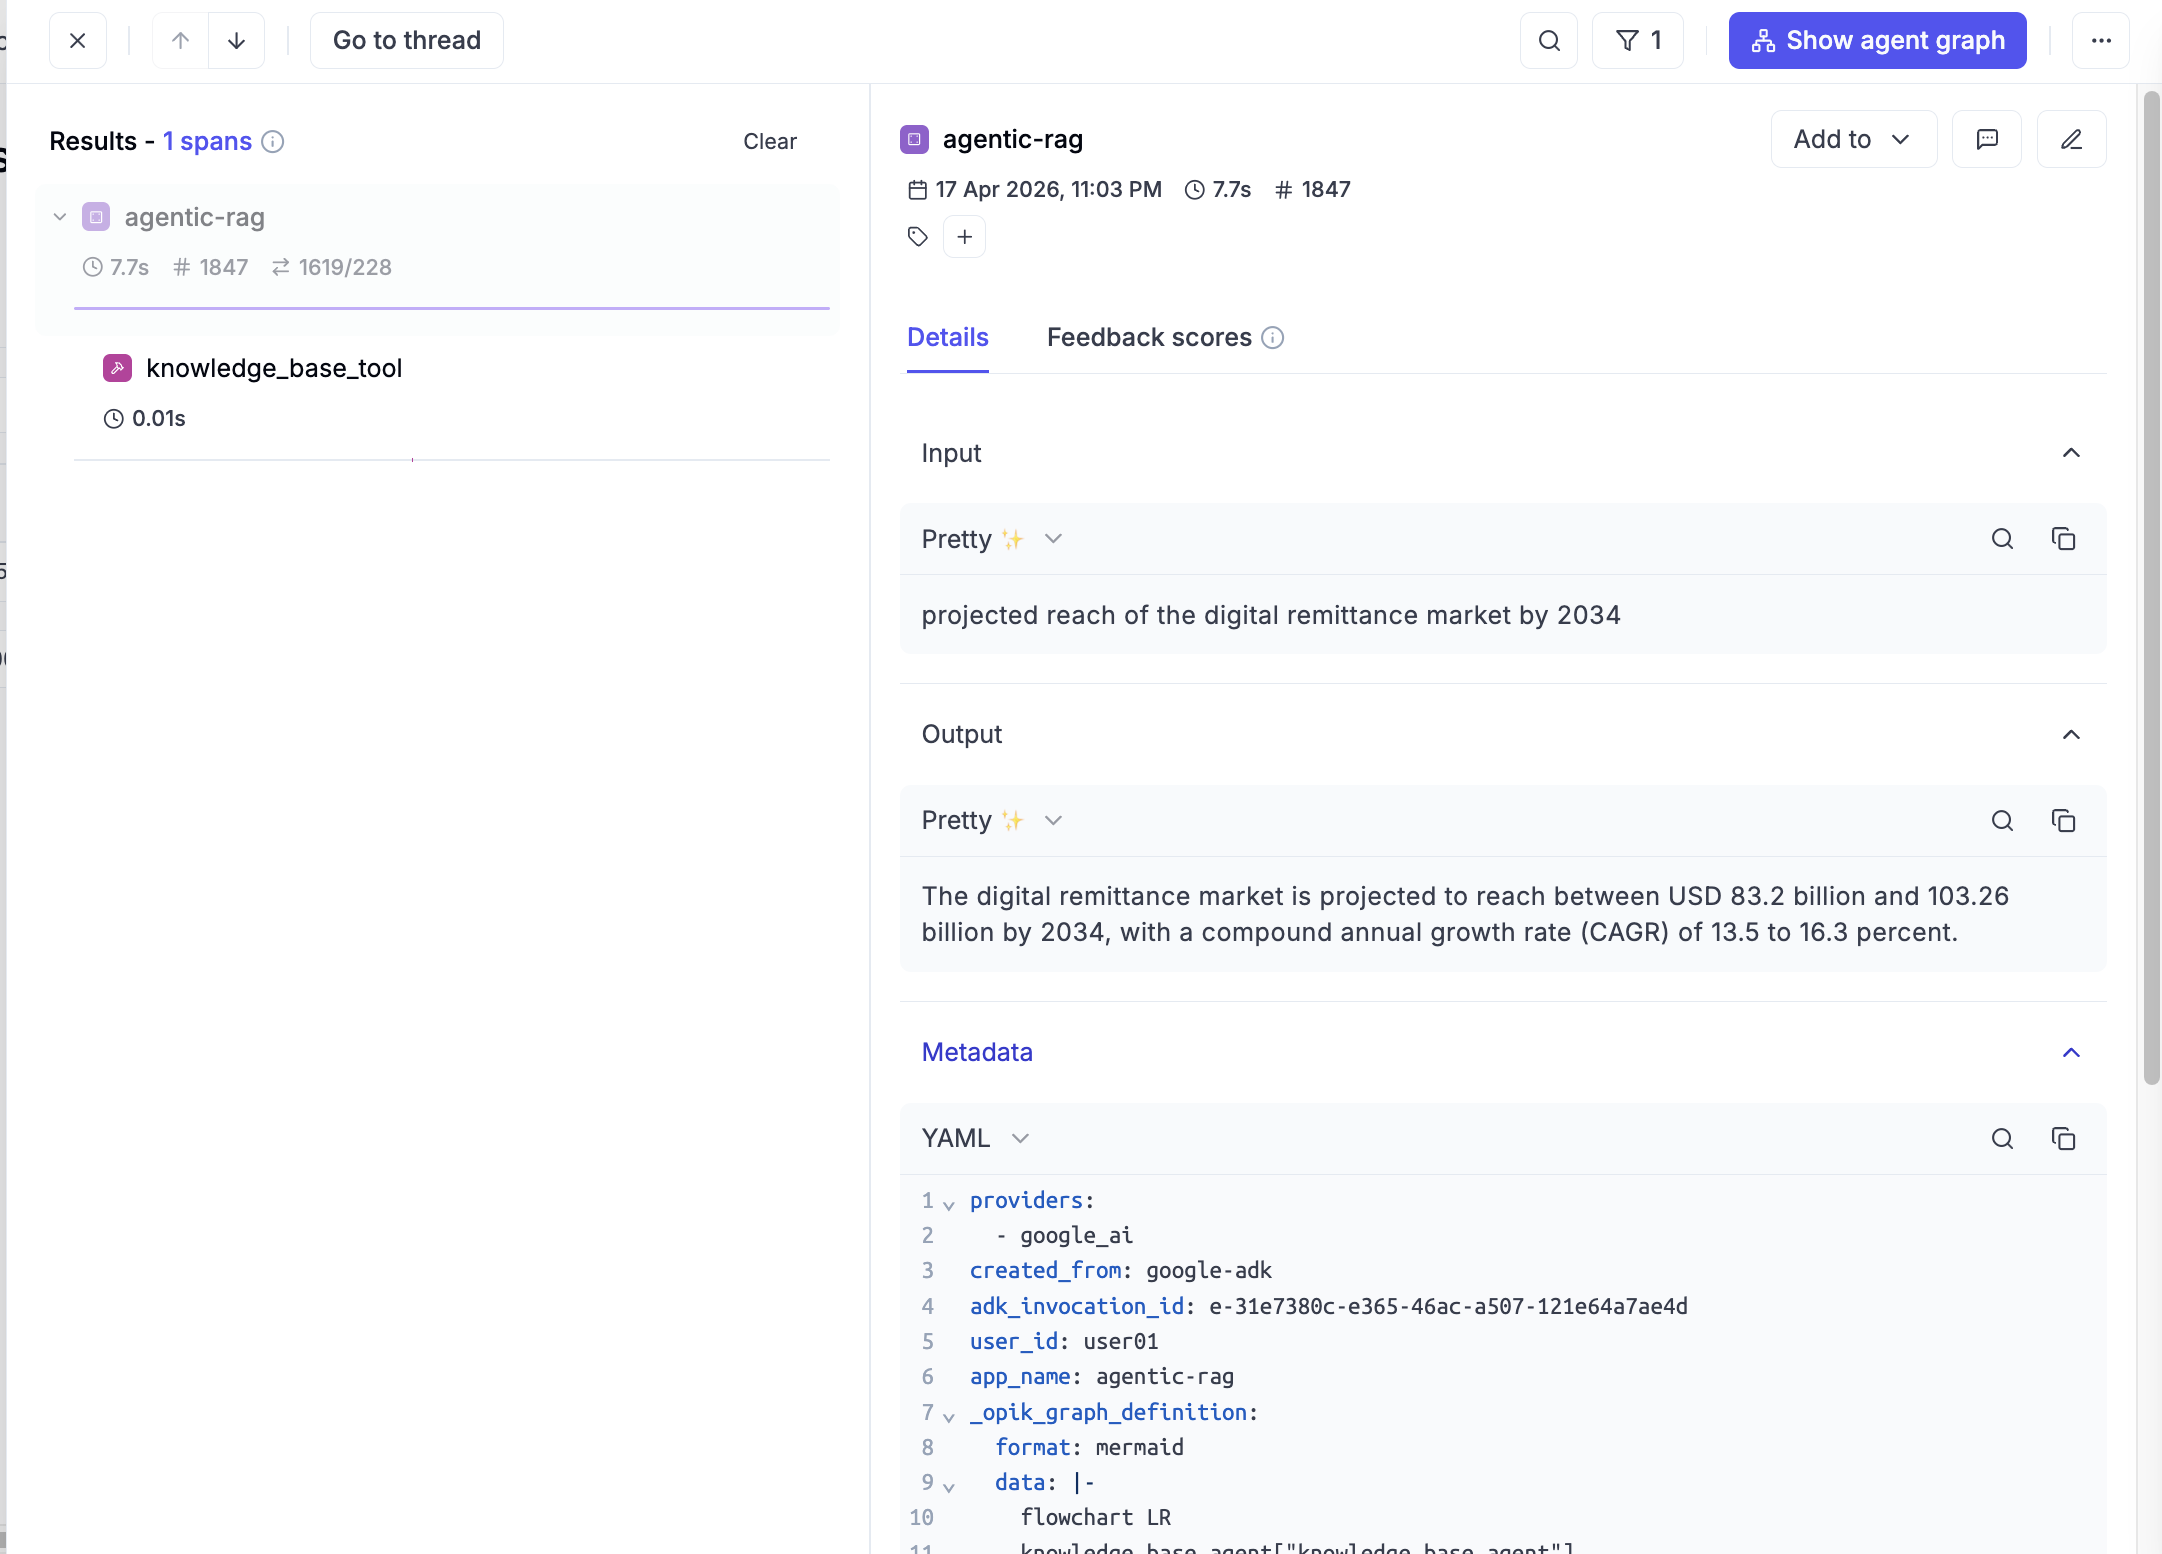

In [66]:
out_of_context = "what is blackhole"

In [67]:
call_agent(out_of_context)

The tool returned a table of contents and some references from the "FINTECH, A CATALYST FOR FINANCIAL SERVICES ACCESS, INNOVATION, AND GROWTH" report.
Nowhere in the returned text is there any mention of a "blackhole".
According to my instructions: "If the tool returns no relevant data, tell the user the information is not available in the report."
